## 1. Import thư viện

In [12]:
import os
import re
import json
import time
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

## Mount Google Drive

Cell này dùng để kết nối Google Drive trong Google Colab.


In [13]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Config

In [14]:
PROJECT_DIR = "/content/drive/MyDrive/Sentimental Analysis"

TRAIN_PATH = f"{PROJECT_DIR}/data_cleanedData/train.csv"
VAL_PATH = f"{PROJECT_DIR}/data_cleanedData/val.csv"
TEST_PATH = f"{PROJECT_DIR}/data_cleanedData/test.csv"

TEXT_COL = "text"
LABEL_COL = "status"

MODEL_DIR = f"{PROJECT_DIR}/model_results/RidgeClassifier"
os.makedirs(MODEL_DIR, exist_ok=True)

RANDOM_STATE = 42


## 3. Cleaning và custom feature extractor

In [15]:
def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"&\w+;", " ", text)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


class CleanTextTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return pd.Series(X).astype(str).apply(clean_text).values


class TextStatFeatures(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.depression_words = {
            "depress", "depressed", "depression", "sad", "hopeless", "empty",
            "worthless", "lonely", "tired", "cry", "crying", "pain", "alone",
            "miserable", "numb", "therapy", "medication"
        }

        self.suicidal_words = {
            "suicide", "suicidal", "kill", "die", "death", "dead", "end",
            "overdose", "selfharm", "self harm", "cut", "hanging", "jump",
            "goodbye", "worthless", "burden"
        }

        self.anxiety_words = {
            "anxiety", "anxious", "panic", "attack", "worry", "worried",
            "fear", "scared", "nervous", "heart", "breath", "breathing",
            "chest", "dizzy", "stress", "overthinking"
        }

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        rows = []

        for text in X:
            raw_text = "" if pd.isna(text) else str(text)
            lower_text = raw_text.lower()
            words = re.findall(r"\b\w+\b", lower_text)

            char_count = len(raw_text)
            word_count = len(words)
            unique_word_count = len(set(words))
            lexical_diversity = unique_word_count / word_count if word_count > 0 else 0.0
            avg_word_length = np.mean([len(w) for w in words]) if len(words) > 0 else 0.0

            exclamation_count = raw_text.count("!")
            question_count = raw_text.count("?")
            digit_count = sum(ch.isdigit() for ch in raw_text)

            alpha_chars = [ch for ch in raw_text if ch.isalpha()]
            uppercase_chars = [ch for ch in raw_text if ch.isupper()]
            uppercase_ratio = len(uppercase_chars) / len(alpha_chars) if len(alpha_chars) > 0 else 0.0

            has_url = int(bool(re.search(r"http\S+|www\S+|https\S+", raw_text)))
            has_mention = int(bool(re.search(r"@\w+", raw_text)))

            depression_count = sum(1 for w in words if w in self.depression_words)
            suicidal_count = sum(1 for w in words if w in self.suicidal_words)
            anxiety_count = sum(1 for w in words if w in self.anxiety_words)

            rows.append([
                char_count,
                word_count,
                unique_word_count,
                lexical_diversity,
                avg_word_length,
                exclamation_count,
                question_count,
                uppercase_ratio,
                digit_count,
                has_url,
                has_mention,
                depression_count,
                suicidal_count,
                anxiety_count
            ])

        return csr_matrix(np.asarray(rows, dtype=np.float32))

## 4. Load dataset

In [16]:
def load_dataset(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Không tìm thấy file: {path}")

    df = pd.read_csv(path)

    if TEXT_COL not in df.columns or LABEL_COL not in df.columns:
        raise ValueError(
            f"File {path} cần có 2 cột '{TEXT_COL}' và '{LABEL_COL}'. "
            f"Các cột hiện có: {list(df.columns)}"
        )

    df = df[[TEXT_COL, LABEL_COL]].dropna()
    df[TEXT_COL] = df[TEXT_COL].astype(str)
    df = df[df[TEXT_COL].str.len() > 0].reset_index(drop=True)
    return df


train_df = load_dataset(TRAIN_PATH)
val_df = load_dataset(VAL_PATH)
test_df = load_dataset(TEST_PATH)

print(f"Train size: {len(train_df):,}")
print(f"Val size:   {len(val_df):,}")
print(f"Test size:  {len(test_df):,}")

train_df[LABEL_COL].value_counts()

Train size: 34,601
Val size:   4,943
Test size:  9,887


,count
status,
normal,12706
depression,10154
suicidal,7840
anxiety,3901


## 5. Build multi-feature pipeline

In [17]:
word_tfidf_pipeline = Pipeline([
    ("clean", CleanTextTransformer()),
    ("tfidf", TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.95,
        max_features=100000,
        sublinear_tf=True,
        strip_accents="unicode"
    ))
])

char_tfidf_pipeline = Pipeline([
    ("clean", CleanTextTransformer()),
    ("tfidf", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=3,
        max_df=0.95,
        max_features=50000,
        sublinear_tf=True,
        strip_accents="unicode"
    ))
])

stat_feature_pipeline = Pipeline([
    ("stats", TextStatFeatures()),
    ("scaler", StandardScaler(with_mean=False))
])

feature_extractor = FeatureUnion([
    ("word_tfidf", word_tfidf_pipeline),
    ("char_tfidf", char_tfidf_pipeline),
    ("stat_features", stat_feature_pipeline)
])

pipeline = Pipeline([
    ("features", feature_extractor),
    ("clf", RidgeClassifier(
        alpha=1.0,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

## 6. Train

In [18]:
X_train = train_df[TEXT_COL]
y_train = train_df[LABEL_COL]

X_val = val_df[TEXT_COL]
y_val = val_df[LABEL_COL]

X_test = test_df[TEXT_COL]
y_test = test_df[LABEL_COL]

print("Training RidgeClassifier...")

start_train = time.perf_counter()
pipeline.fit(X_train, y_train)
train_time = time.perf_counter() - start_train

print("Training done.")
print(f"Training time: {train_time:.4f} seconds")


Training RidgeClassifier...
Training done.
Training time: 140.0980 seconds


## 7. Confusion matrix

In [19]:
def plot_confusion_matrix_png(cm, labels, split_name, normalize=False):
    if normalize:
        cm_to_plot = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cm_to_plot = np.nan_to_num(cm_to_plot)
        values_format = ".2f"
        title = f"{split_name.upper()} Normalized Confusion Matrix"
        file_name = f"{split_name}_confusion_matrix_normalized.png"
    else:
        cm_to_plot = cm
        values_format = "d"
        title = f"{split_name.upper()} Confusion Matrix"
        file_name = f"{split_name}_confusion_matrix.png"

    fig, ax = plt.subplots(figsize=(8, 6))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_to_plot,
        display_labels=labels
    )

    disp.plot(
        ax=ax,
        cmap="YlGnBu",
        values_format=values_format,
        xticks_rotation=45,
        colorbar=True
    )

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    plt.tight_layout()

    save_path = os.path.join(MODEL_DIR, file_name)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved confusion matrix plot: {save_path}")

## 8. Evaluate

===== VAL RESULT =====
Accuracy:             0.7864
Macro F1:             0.7730
Weighted F1:          0.7833
Inference time total: 6.8480 seconds
Avg inference time:   0.00138539 seconds/sample

              precision    recall  f1-score   support

     anxiety     0.7917    0.8259    0.8084       557
  depression     0.7335    0.6527    0.6907      1451
      normal     0.8845    0.9455    0.9140      1815
    suicidal     0.6755    0.6821    0.6788      1120

    accuracy                         0.7864      4943
   macro avg     0.7713    0.7765    0.7730      4943
weighted avg     0.7824    0.7864    0.7833      4943



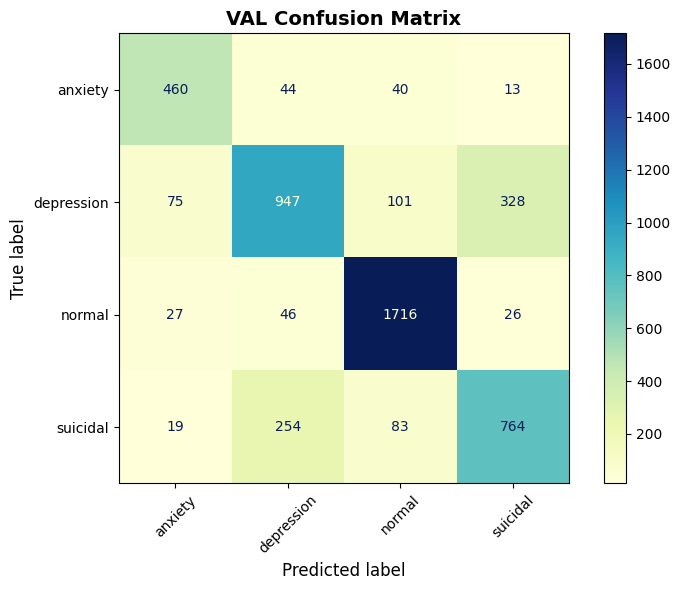

Saved confusion matrix plot: /content/drive/MyDrive/Sentimental Analysis/model_results/RidgeClassifier/val_confusion_matrix.png


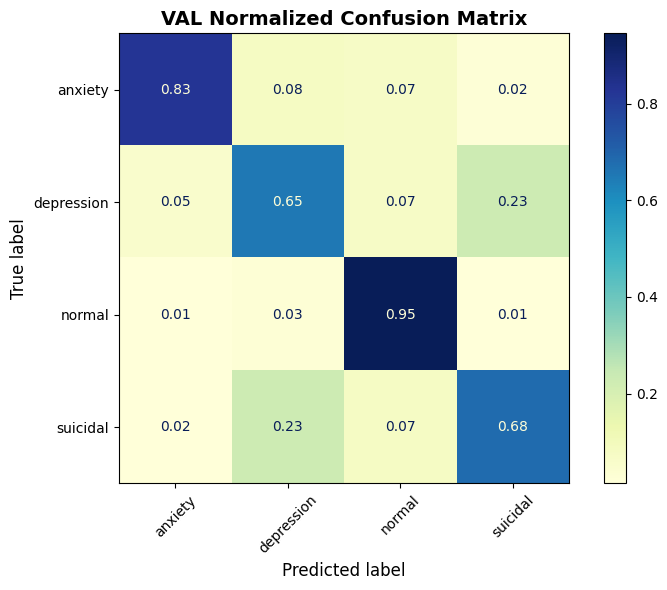

Saved confusion matrix plot: /content/drive/MyDrive/Sentimental Analysis/model_results/RidgeClassifier/val_confusion_matrix_normalized.png
===== TEST RESULT =====
Accuracy:             0.7863
Macro F1:             0.7720
Weighted F1:          0.7843
Inference time total: 9.0139 seconds
Avg inference time:   0.00091169 seconds/sample

              precision    recall  f1-score   support

     anxiety     0.7728    0.8117    0.7918      1115
  depression     0.7286    0.6551    0.6899      2902
      normal     0.8965    0.9333    0.9146      3630
    suicidal     0.6787    0.7054    0.6918      2240

    accuracy                         0.7863      9887
   macro avg     0.7692    0.7764    0.7720      9887
weighted avg     0.7839    0.7863    0.7843      9887



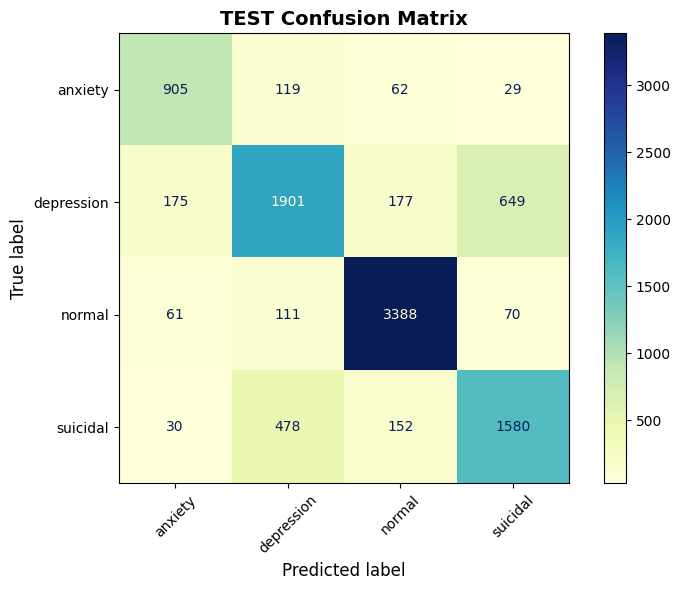

Saved confusion matrix plot: /content/drive/MyDrive/Sentimental Analysis/model_results/RidgeClassifier/test_confusion_matrix.png


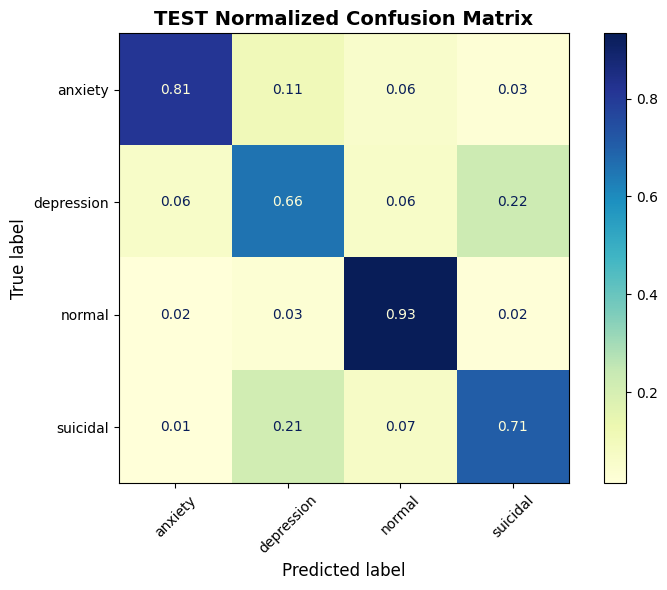

Saved confusion matrix plot: /content/drive/MyDrive/Sentimental Analysis/model_results/RidgeClassifier/test_confusion_matrix_normalized.png


In [20]:
def evaluate_model(split_name, X, y_true):
    start_infer = time.perf_counter()
    y_pred = pipeline.predict(X)
    infer_time_total = time.perf_counter() - start_infer
    infer_time_avg = infer_time_total / len(X)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    print(f"===== {split_name.upper()} RESULT =====")
    print(f"Accuracy:             {acc:.4f}")
    print(f"Macro F1:             {macro_f1:.4f}")
    print(f"Weighted F1:          {weighted_f1:.4f}")
    print(f"Inference time total: {infer_time_total:.4f} seconds")
    print(f"Avg inference time:   {infer_time_avg:.8f} seconds/sample")
    print()

    print(classification_report(y_true, y_pred, digits=4))

    labels = sorted(pd.Series(y_true).unique())
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    pred_df = pd.DataFrame({
        "text": X.values,
        "true_label": y_true.values,
        "pred_label": y_pred
    })
    pred_df.to_csv(os.path.join(MODEL_DIR, f"{split_name}_predictions.csv"), index=False)

    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    cm_df.to_csv(os.path.join(MODEL_DIR, f"{split_name}_confusion_matrix.csv"))

    plot_confusion_matrix_png(cm, labels, split_name, normalize=False)
    plot_confusion_matrix_png(cm, labels, split_name, normalize=True)

    report_dict = classification_report(y_true, y_pred, digits=4, output_dict=True)
    with open(os.path.join(MODEL_DIR, f"{split_name}_classification_report.json"), "w", encoding="utf-8") as f:
        json.dump(report_dict, f, indent=4, ensure_ascii=False)

    return {
        "split": split_name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "infer_time_total_sec": infer_time_total,
        "infer_time_avg_sec_per_sample": infer_time_avg
    }


val_metrics = evaluate_model("val", X_val, y_val)
test_metrics = evaluate_model("test", X_test, y_test)


## 9. Save model

In [21]:
model_path = os.path.join(MODEL_DIR, "multi_feature_ridge_classifier.joblib")
joblib.dump(pipeline, model_path)

metrics = {
    "model": "Multi-feature extraction + RidgeClassifier",
    "training_time_sec": train_time,
    "val": val_metrics,
    "test": test_metrics,
    "val_infer_time_total_sec": val_metrics["infer_time_total_sec"],
    "val_infer_time_avg_sec_per_sample": val_metrics["infer_time_avg_sec_per_sample"],
    "test_infer_time_total_sec": test_metrics["infer_time_total_sec"],
    "test_infer_time_avg_sec_per_sample": test_metrics["infer_time_avg_sec_per_sample"]
}

with open(os.path.join(MODEL_DIR, "metrics_summary.json"), "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=4, ensure_ascii=False)

print(f"Saved model to: {model_path}")
print(f"Saved metrics to: {os.path.join(MODEL_DIR, 'metrics_summary.json')}")


Saved model to: /content/drive/MyDrive/Sentimental Analysis/model_results/RidgeClassifier/multi_feature_ridge_classifier.joblib
Saved metrics to: /content/drive/MyDrive/Sentimental Analysis/model_results/RidgeClassifier/metrics_summary.json


## 10. Predict thử

In [22]:
def predict_text(text):
    return pipeline.predict([text])[0]

sample_text = "I feel anxious and my heart is racing all the time"
print(predict_text(sample_text))

anxiety
